In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_excel("AirbnbHotelBookingAnalysis.xlsx")
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  str           
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  str           
 6   neighbourhood                   102583 non-null  str           
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  str           
 10  country code                    102468 non-null  str           
 11

In [4]:
df.duplicated().value_counts()

False    102058
True        541
Name: count, dtype: int64

In [5]:
df[df['neighbourhood group'] == 'brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,116.0,4.0,167.0,2019-06-24,1.34,4.0,3.0,47.0,NaN,NaN


In [8]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

id                                    0
NAME                                270
host id                               0
host_identity_verified              289
host name                           408
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
country                             532
country code                        131
instant_bookable                    105
cancellation_policy                  76
room type                             0
Construction year                   214
price                               247
service fee                         273
minimum nights                      409
number of reviews                   183
last review                       15893
reviews per month                 15879
review rate number                  326
calculated host listings count      319
availability 365                    448
dtype: int64


In [11]:
# Check current columns
print(df.columns.tolist())

['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']


In [12]:
# Remove dollar signs and commas from price columns
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)

df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False)
df['service fee'] = df['service fee'].str.replace(',', '', regex=False)

# Rename price and service fee columns
df.rename(columns={
    'price': 'price_$',
    'service fee': 'service_fee_$'
}, inplace=True)

# Check the updated columns
print(df.columns.tolist())

['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price_$', 'service_fee_$', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']


In [13]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Change columns to appropriate data types
df['price_$'] = pd.to_numeric(df['price_$'], errors='coerce')
df['service_fee_$'] = pd.to_numeric(df['service_fee_$'], errors='coerce')

df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)

df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

df['Construction year'] = pd.to_numeric(
    df['Construction year'], errors='coerce'
).astype('Int64')

# Check data types
print(df.dtypes)

id                                           str
NAME                                      object
host id                                      str
host_identity_verified                       str
host name                                 object
neighbourhood group                          str
neighbourhood                                str
lat                                      float64
long                                     float64
country                                      str
country code                                 str
instant_bookable                         float64
cancellation_policy                          str
room type                                    str
Construction year                          Int64
price_$                                  float64
service_fee_$                            float64
minimum nights                           float64
number of reviews                        float64
last review                       datetime64[us]
reviews per month   

In [14]:
# Correct the spelling of 'brookln' to 'Brooklyn'
df.loc[
    df['neighbourhood group'] == 'brookln',
    'neighbourhood group'
] = 'Brooklyn'

# Remove outliers from 'availability 365'
df = df[df['availability 365'] <= 500]

# Check the number of rows after removing outliers
print("Rows after cleaning:", len(df))

Rows after cleaning: 101609


In [15]:
# Check remaining missing values
print(df.isnull().sum())

id                                    0
NAME                                252
host id                               0
host_identity_verified              281
host name                           393
neighbourhood group                  18
neighbourhood                        15
lat                                   8
long                                  8
country                             525
country code                        124
instant_bookable                     98
cancellation_policy                  69
room type                             0
Construction year                   195
price_$                             247
service_fee_$                       273
minimum nights                      378
number of reviews                   129
last review                       15564
reviews per month                 15557
review rate number                  305
calculated host listings count      319
availability 365                      0
dtype: int64


In [16]:
# Remove all remaining records with missing values
df.dropna(inplace=True)

# Check the final missing values
print(df.isnull().sum())

# Check final dataset size
print("Final dataset shape:", df.shape)

id                                0
NAME                              0
host id                           0
host_identity_verified            0
host name                         0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
country                           0
country code                      0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price_$                           0
service_fee_$                     0
minimum nights                    0
number of reviews                 0
last review                       0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
dtype: int64
Final dataset shape: (83389, 24)


In [17]:
# Display basic statistical summary of the cleaned dataset
df.describe()

,lat,long,instant_bookable,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,83389.000000,83389.000000,83389.000000,83389.0,83389.000000,83389.000000,83389.000000,83389.000000,83389,83389.000000,83389.000000,83389.000000,83389.000000
mean,40.727349,-73.948502,0.497704,2012.48781,626.209668,125.243114,7.406109,32.261305,2019-06-08 21:32:53.396970,1.377352,3.278694,7.032894,141.746369
min,40.504560,-74.249840,0.000000,2003.0,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.687640,-73.982110,0.000000,2007.0,340.000000,68.000000,2.000000,3.000000,2018-10-25 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,40.721320,-73.953710,0.000000,2012.0,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,40.762600,-73.930800,1.000000,2017.0,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,40.916970,-73.705220,1.000000,2022.0,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,426.000000
std,0.056326,0.050342,0.499998,5.760526,331.803443,66.364212,28.105563,51.954290,NaN,1.751091,1.283678,29.555458,133.377544


In [18]:
# Remove invalid values from minimum nights
df = df[df['minimum nights'] > 0]

# Keep availability between 0 and 365 days
df = df[
    (df['availability 365'] >= 0) &
    (df['availability 365'] <= 365)
]

# Check the dataset after removing invalid values
print("Dataset shape after final cleaning:", df.shape)

# Check minimum values
print("\nMinimum values:")
print(df[['minimum nights', 'availability 365']].min())

Dataset shape after final cleaning: (80903, 24)

Minimum values:
minimum nights      1.0
availability 365    0.0
dtype: float64


In [20]:
# What are the different property types in the Dataset?
property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,42746
Private room,36438
Shared room,1611
Hotel room,108


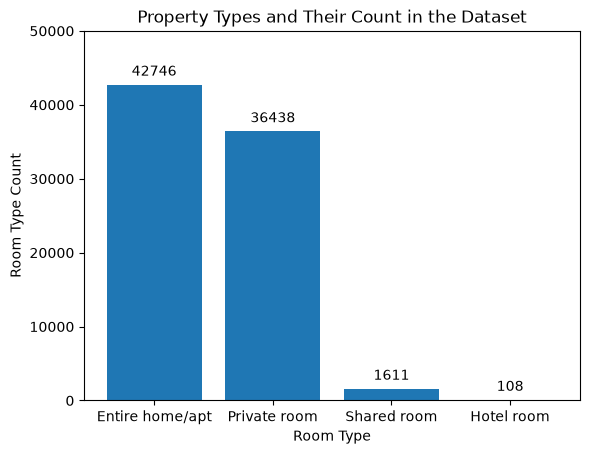

In [23]:
# Room type count plotted on a bar chart
room_type_bar = plt.bar(
    property_types.index,
    property_types['count']
);

plt.bar_label(
    room_type_bar,
    labels=property_types['count'],
    padding=4
);
plt.ylim([0,50000]);
plt.xlabel('Room Type');
plt.ylabel('Room Type Count');
plt.title('Property Types and Their Count in the Dataset');

In [24]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,33568
Manhattan,33388
Queens,10912
Bronx,2235
Staten Island,800


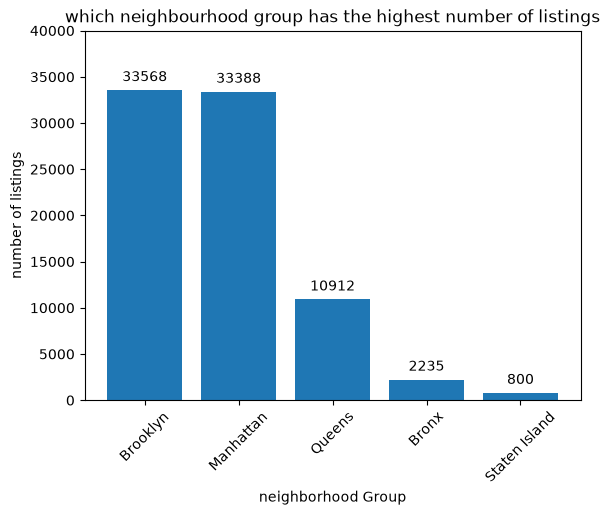

In [25]:
#which neighbourhood group has the highest number of listings?
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:,'count']);
plt.bar_label(hood_group_bar,label = hood_group.loc[:,'count'],padding= 4);
plt.ylim([0,40000]);
plt.xlabel('neighborhood Group');
plt.ylabel('number of listings');
plt.xticks(rotation = 45);
plt.title('which neighbourhood group has the highest number of listings');

Text(0.5, 1.0, 'Average Price per Listing ($) in Each Neighborhood Group')

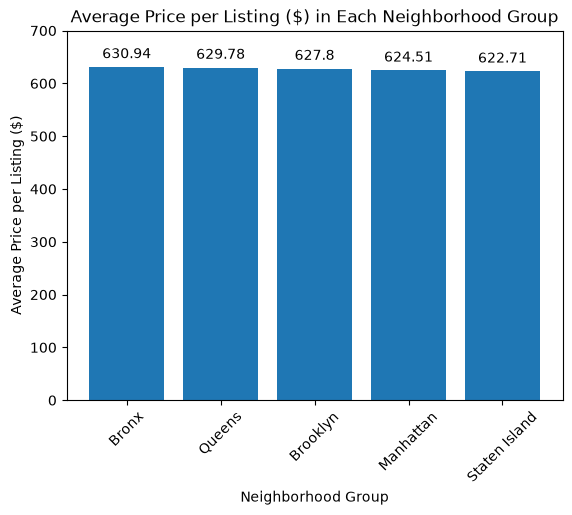

In [27]:
# Which neighborhood group has the highest average prices for Airbnb listings?
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending=False).to_frame()

avg_price_bar = plt.bar(avg_price.index, avg_price['price_$'])
plt.bar_label(avg_price_bar, labels=round(avg_price['price_$'], 2), padding=4)

plt.ylim([0, 700])
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Price per Listing ($)')
plt.xticks(rotation=45)
plt.title('Average Price per Listing ($) in Each Neighborhood Group')

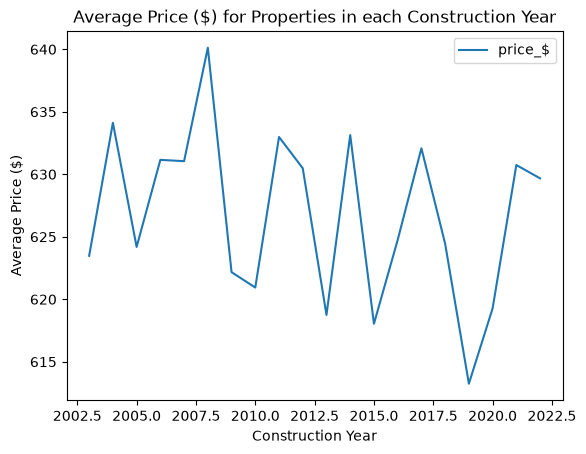

In [28]:
#Is there a relationship between the construction year of property and price?
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price ($)');
plt.title('Average Price ($) for Properties in each Construction Year');

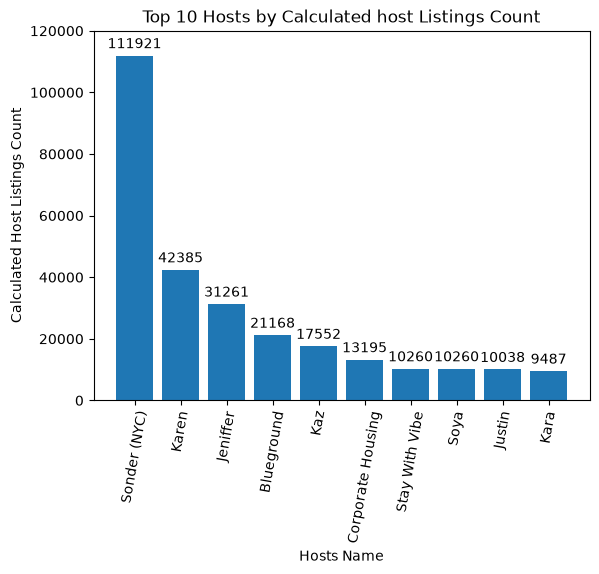

In [29]:
#Who are the top 10 hosts by calculated host listing count?
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index, hosts.loc[:, 'calculated host listings count']);
plt.bar_label(hosts_bar, label = hosts.loc[:, 'calculated host listings count'], label_type = 'edge', padding = 3);
plt.xlabel('Hosts Name');
plt.ylabel('Calculated Host Listings Count');
plt.xticks(rotation = 80);
plt.ylim([0, 120000]);
plt.title('Top 10 Hosts by Calculated host Listings Count');

In [30]:
# Are hosts with verified identities more likely to receive positive reviews?
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.290707
unconfirmed,3.284202


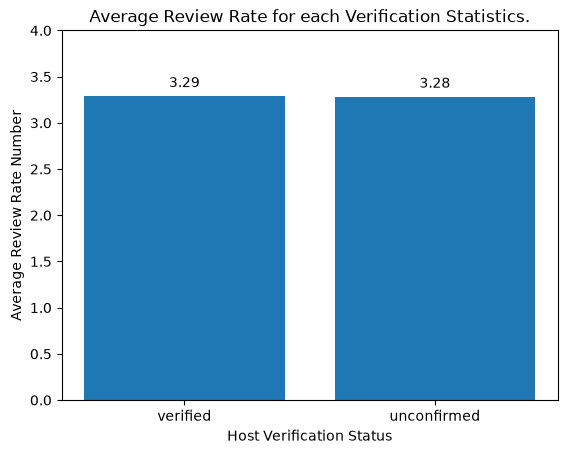

In [31]:
review_bar = plt.bar(review.index, review.loc[:,"review rate number"]);
plt.bar_label(review_bar, labels = round(review.loc[:,"review rate number"], 2), padding = 4 );
plt.ylim([0,4]);
plt.xlabel('Host Verification Status');
plt.ylabel('Average Review Rate Number');
plt.title('Average Review Rate for each Verification Statistics.');


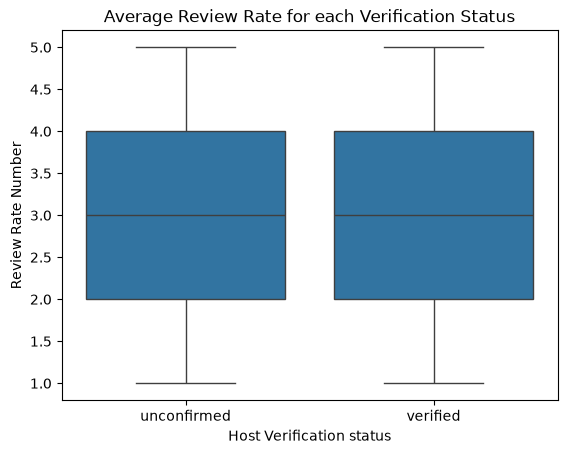

In [32]:
base_color = sns.color_palette()[0]
sns.boxplot(data = df, x = "host_identity_verified", y = "review rate number", color = base_color);
plt.xlabel('Host Verification status');
plt.ylabel('Review Rate Number');
plt.title('Average Review Rate for each Verification Status');


In [33]:
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999909009940567)

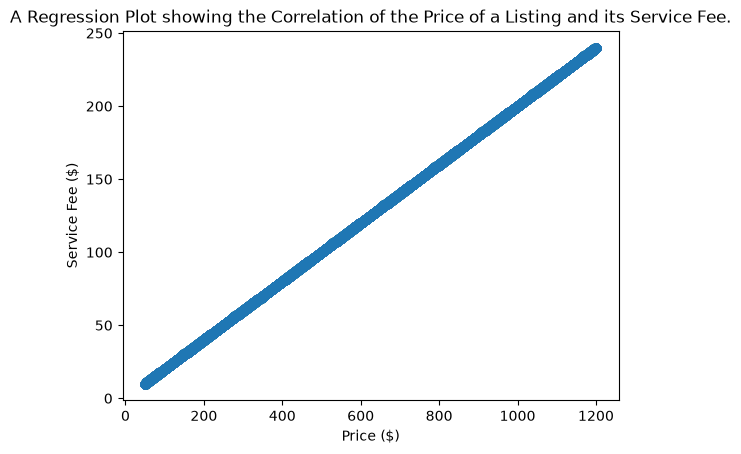

In [34]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$');
plt.xlabel('Price ($)');
plt.ylabel('Service Fee ($)');
plt.title('A Regression Plot showing the Correlation of the Price of a Listing and its Service Fee.');


In [35]:
#what is the average review rate number (e.g., stars) for listings, and does it vary based on the neighborhood group and room type?
ARRN = df.groupby(['neighbourhood group', 'room type'])['review rate number'].mean().to_frame()
ARRN


review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.379791
                    Private room               3.321678
                    Shared room                3.356322
Brooklyn            Entire home/apt            3.252007
                    Hotel room                 3.833333
                    Private room               3.285108
                    Shared room                3.328859
Manhattan           Entire home/apt            3.276217
                    Hotel room                 3.500000
                    Private room               3.293262
                    Shared room                3.272868
Queens              Entire home/apt            3.358028
                    Hotel room                 3.750000
                    Private room               3.320198
                    Shared room                3.326087
Staten Island       Entire home/apt            3.337408
                    Private room               3.489583
                    Shared room                3.714286

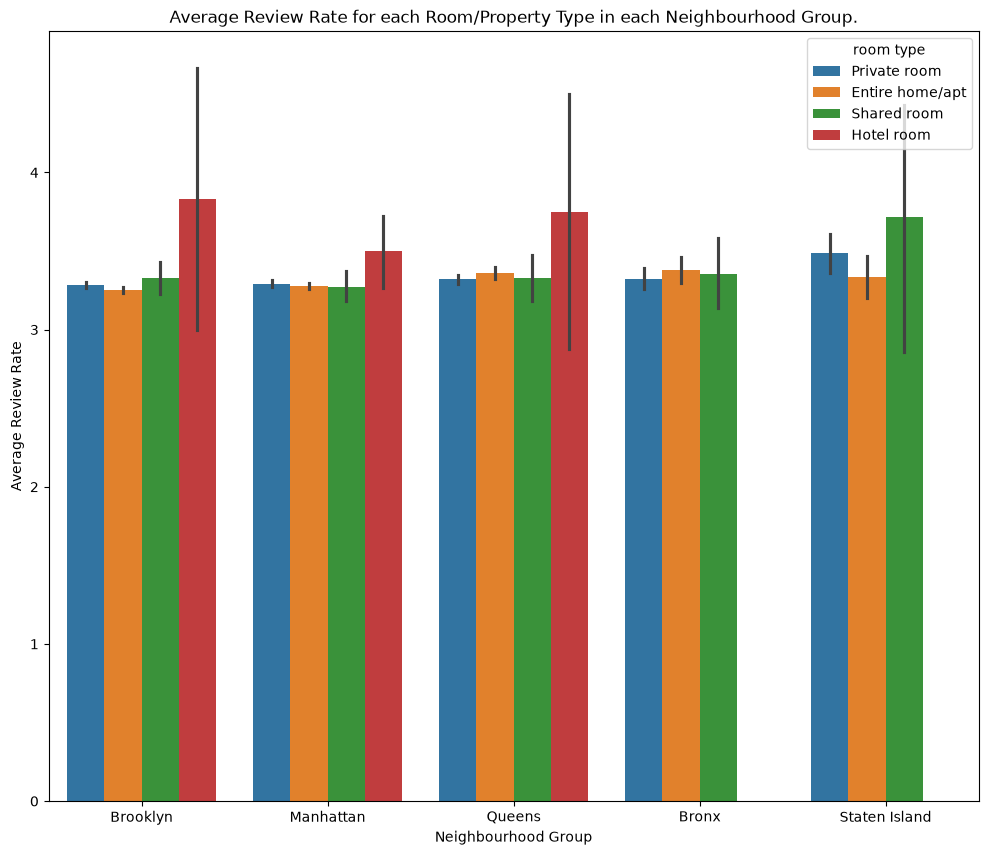

In [36]:
plt.figure(figsize = [12,10]);
sns.barplot(data = df, x = 'neighbourhood group', y = 'review rate number', hue = 'room type' );
plt.xlabel('Neighbourhood Group');
plt.ylabel('Average Review Rate');
plt.title('Average Review Rate for each Room/Property Type in each Neighbourhood Group.');


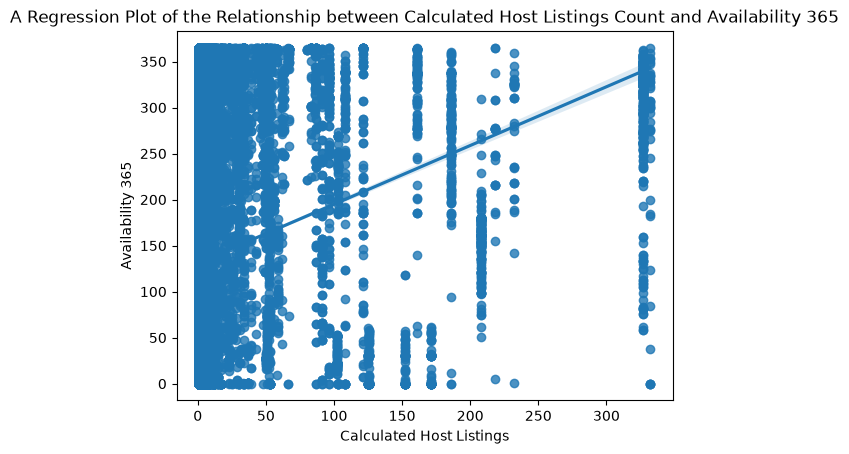

In [37]:
#Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?
sns.regplot(data = df, x = 'calculated host listings count', y = 'availability 365');
plt.xlabel('Calculated Host Listings');
plt.ylabel('Availability 365');
plt.title('A Regression Plot of the Relationship between Calculated Host Listings Count and Availability 365');


In [38]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.1486290882160245)